# GPT-5-mini / GPT-5.2 Few-Shot Confidence Intervals

Simple, focused version: just the 2 GPT models, just the 5 few-shot conditions,
across all 3 seeds (42 original, 101, 202). Same bootstrap logic as the other
notebooks (resample instances, and for few-shot also randomly draw a seed per
replicate), just scoped down.

10 of 90 (dataset, model, prompt, seed) cells have a known parsing bug (GPT-5-series
response sometimes comes back empty -- see data-quality check below) and are
automatically excluded, same as everywhere else in this project.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

BASE = "/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper"
CLASSES = ["FAVOR", "AGAINST", "NONE"]
FEWSHOT_PROMPTS = ["few_shot_3", "few_shot_6", "few_shot_9", "few_shot_12", "few_shot_15"]
DATASETS = ["semeval", "ezstance", "mtcsd"]
SEEDS = [42, 101, 202]
MODELS = ["GPT-5-mini", "GPT-5.2"]
MODEL_RAW = {"gpt-5-mini": "GPT-5-mini", "gpt-5.2": "GPT-5.2"}

DATASET_DIRS_BY_SEED = {
    42: {"semeval": ["data_out/stance/semeval_results"], "ezstance": ["data_out/stance/ezstance_test"],
         "mtcsd": ["data_out/stance/mtcsd_test_results", "data_out/stance/mtcsd_test"]},
    101: {"semeval": ["data_out/few_shot_seed101/semeval2016_task6_testdata_gold"],
          "ezstance": ["data_out/few_shot_seed101/ezstance_test"], "mtcsd": ["data_out/few_shot_seed101/mtcsd_test"]},
    202: {"semeval": ["data_out/few_shot_seed202/semeval2016_task6_testdata_gold"],
          "ezstance": ["data_out/few_shot_seed202/ezstance_test"], "mtcsd": ["data_out/few_shot_seed202/mtcsd_test"]},
}


def normalize_label(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    if s == "FAVOR":
        return "FAVOR"
    if s == "AGAINST":
        return "AGAINST"
    if s in ("NONE", "NEUTRAL", "NEITHER"):
        return "NONE"
    return None


def load_predictions(seed, dataset):
    rows = []
    for rel_dir in DATASET_DIRS_BY_SEED[seed][dataset]:
        full_dir = os.path.join(BASE, rel_dir)
        if not os.path.isdir(full_dir):
            continue
        for folder in sorted(os.listdir(full_dir)):
            folder_path = os.path.join(full_dir, folder)
            summary_path = os.path.join(folder_path, "summary.json")
            assignments_path = os.path.join(folder_path, "document_assignments.csv")
            if not (os.path.isdir(folder_path) and os.path.exists(summary_path) and os.path.exists(assignments_path)):
                continue
            cfg = json.load(open(summary_path)).get("configuration", {})
            model_raw = cfg.get("openai_model", "")
            if model_raw not in MODEL_RAW:
                continue
            prompt = cfg.get("stance_prompt_name", "")
            if prompt not in FEWSHOT_PROMPTS:
                continue
            df = pd.read_csv(assignments_path)
            if "run" in df.columns:
                df = df[df["run"] == 0]
            df["gold"] = df["original_stance"].apply(normalize_label)
            df["pred"] = df["predicted_stance"].apply(normalize_label)
            df["dataset"] = dataset
            df["model"] = MODEL_RAW[model_raw]
            df["prompt"] = prompt
            df["seed"] = seed
            rows.append(df[["dataset", "model", "prompt", "seed", "gold", "pred"]])
    if not rows:
        return pd.DataFrame(columns=["dataset", "model", "prompt", "seed", "gold", "pred"])
    return pd.concat(rows, ignore_index=True)


predictions = pd.concat([load_predictions(s, d) for s in SEEDS for d in DATASETS], ignore_index=True)
print(f"Loaded {len(predictions):,} prediction rows")


Loaded 188,490 prediction rows


## Data-quality check

Same 95%-valid-prediction-rate filter as everywhere else -- excludes the known GPT-5 empty-response bug automatically.

In [2]:
validity = (
    predictions.assign(valid=lambda d: d["gold"].notna() & d["pred"].notna())
    .groupby(["dataset", "model", "prompt", "seed"])
    .agg(n_total=("valid", "size"), n_valid=("valid", "sum"))
    .reset_index()
)
validity["valid_rate"] = validity["n_valid"] / validity["n_total"]
bad = validity[validity["valid_rate"] < 0.95].sort_values("valid_rate")
print(f"{len(bad)} / {len(validity)} cells excluded (below 95% valid-prediction rate)")
clean_keys = set(map(tuple, validity[validity["valid_rate"] >= 0.95][["dataset", "model", "prompt", "seed"]].values))


10 / 90 cells excluded (below 95% valid-prediction rate)


## Bootstrap CI table

One row per (dataset, model, shot-count): each replicate randomly picks one of the available clean seeds, then resamples instances within it -- same procedure used throughout this project for few-shot cells.

In [3]:
RNG = np.random.default_rng(42)
N_BOOT = 1000
LABEL_TO_CODE = {"FAVOR": 0, "AGAINST": 1, "NONE": 2}
MACRO_F1_CODES = [0, 1, 2]
FAVG_CODES = [0, 1]


def _encode(labels_array):
    return np.array([LABEL_TO_CODE[x] for x in labels_array], dtype=np.int8)


def macro_f1_arrays(gold, pred):
    return f1_score(gold, pred, labels=CLASSES, average=None, zero_division=0).mean()


def favg_arrays(gold, pred):
    f_favor = f1_score(gold, pred, labels=["FAVOR"], average="macro", zero_division=0)
    f_against = f1_score(gold, pred, labels=["AGAINST"], average="macro", zero_division=0)
    return (f_favor + f_against) / 2


def metric_for(dataset):
    return favg_arrays if dataset == "mtcsd" else macro_f1_arrays


def _f1_bootstrap_vectorized(gold_codes, pred_codes, n_boot, rng, avg_over_codes):
    n = len(gold_codes)
    idx = rng.integers(0, n, size=(n_boot, n))
    g, p = gold_codes[idx], pred_codes[idx]
    f1_sum = np.zeros(n_boot)
    for c in avg_over_codes:
        tp = np.sum((g == c) & (p == c), axis=1)
        fp = np.sum((g != c) & (p == c), axis=1)
        fn = np.sum((g == c) & (p != c), axis=1)
        denom = 2 * tp + fp + fn
        f1_sum += np.where(denom > 0, 2 * tp / np.maximum(denom, 1), 0.0)
    return f1_sum / len(avg_over_codes)


def _seed_arrays(dataset, model, prompt):
    out = {}
    for s in SEEDS:
        if (dataset, model, prompt, s) not in clean_keys:
            continue
        sub = predictions[
            (predictions["dataset"] == dataset) & (predictions["model"] == model)
            & (predictions["prompt"] == prompt) & (predictions["seed"] == s)
        ]
        sub = sub[sub["gold"].notna() & sub["pred"].notna()]
        if len(sub) > 0:
            out[s] = (_encode(sub["gold"].values), _encode(sub["pred"].values))
    return out


def bootstrap_cell(dataset, model, prompt, n_boot=N_BOOT, rng=RNG):
    seed_data = _seed_arrays(dataset, model, prompt)
    if not seed_data:
        return np.nan, np.nan, np.nan, 0
    avg_codes = FAVG_CODES if dataset == "mtcsd" else MACRO_F1_CODES
    s0 = 42 if 42 in seed_data else next(iter(seed_data))
    inv_map = {v: k for k, v in LABEL_TO_CODE.items()}
    gold0, pred0 = seed_data[s0]
    point = metric_for(dataset)(np.vectorize(inv_map.get)(gold0), np.vectorize(inv_map.get)(pred0))

    available = list(seed_data.keys())
    draws = rng.integers(0, len(available), size=n_boot)
    scores = np.empty(n_boot)
    for si, s in enumerate(available):
        mask = draws == si
        k = int(mask.sum())
        if k == 0:
            continue
        gold, pred = seed_data[s]
        scores[mask] = _f1_bootstrap_vectorized(gold, pred, k, rng, avg_codes)
    lo, hi = np.percentile(scores, [2.5, 97.5])
    return point, lo, hi, len(available)


_rows = []
for dataset in DATASETS:
    for model in MODELS:
        for prompt in FEWSHOT_PROMPTS:
            point, lo, hi, n_seeds = bootstrap_cell(dataset, model, prompt)
            if not np.isnan(point):
                _rows.append({"dataset": dataset, "model": model, "prompt": prompt,
                              "point": point, "ci_lo": lo, "ci_hi": hi, "n_seeds": n_seeds})
per_cell_ci = pd.DataFrame(_rows)
out_path = os.path.join(BASE, "data_out/stance/stance_analysis/gpt_fewshot_per_cell_ci.csv")
per_cell_ci.to_csv(out_path, index=False)
print(f"Saved {len(per_cell_ci)} rows -> {out_path}")
display(per_cell_ci)


Saved 30 rows -> /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/stance_analysis/gpt_fewshot_per_cell_ci.csv


,dataset,model,prompt,point,ci_lo,ci_hi,n_seeds
0,semeval,GPT-5-mini,few_shot_3,0.736399,0.707459,0.759219,3
1,semeval,GPT-5-mini,few_shot_6,0.735923,0.712083,0.762383,1
2,semeval,GPT-5-mini,few_shot_9,0.756357,0.715248,0.776368,2
3,semeval,GPT-5-mini,few_shot_12,0.755250,0.711890,0.776226,2
4,semeval,GPT-5-mini,few_shot_15,0.737541,0.710413,0.762145,1
5,semeval,GPT-5.2,few_shot_3,0.738681,0.700554,0.758481,2
6,semeval,GPT-5.2,few_shot_6,0.757970,0.696523,0.774905,3
7,semeval,GPT-5.2,few_shot_9,0.743987,0.695458,0.762336,3
8,semeval,GPT-5.2,few_shot_12,0.744853,0.697044,0.762663,3
9,semeval,GPT-5.2,few_shot_15,0.741943,0.696323,0.759793,3


## Scatter plot: pooled across the 5 few-shot conditions

One dot + 95% CI per model per dataset -- each replicate averages across all 5 shot-counts (each independently seed-drawn + instance-resampled), matching the stratified-bootstrap approach used for the full 11-prompt version.

In [4]:
def bootstrap_overall(dataset, model, n_boot=N_BOOT, rng=RNG):
    avg_codes = FAVG_CODES if dataset == "mtcsd" else MACRO_F1_CODES
    inv_map = {v: k for k, v in LABEL_TO_CODE.items()}
    prompt_seed_data = {p: _seed_arrays(dataset, model, p) for p in FEWSHOT_PROMPTS}
    prompt_seed_data = {p: sd for p, sd in prompt_seed_data.items() if sd}
    if not prompt_seed_data:
        return np.nan, np.nan, np.nan

    point_vals = []
    replicate_scores_per_prompt = []
    for prompt, sd in prompt_seed_data.items():
        s0 = 42 if 42 in sd else next(iter(sd))
        gold0, pred0 = sd[s0]
        point_vals.append(metric_for(dataset)(np.vectorize(inv_map.get)(gold0), np.vectorize(inv_map.get)(pred0)))

        available = list(sd.keys())
        draws = rng.integers(0, len(available), size=n_boot)
        scores = np.empty(n_boot)
        for si, s in enumerate(available):
            mask = draws == si
            k = int(mask.sum())
            if k == 0:
                continue
            gold, pred = sd[s]
            scores[mask] = _f1_bootstrap_vectorized(gold, pred, k, rng, avg_codes)
        replicate_scores_per_prompt.append(scores)

    point = float(np.mean(point_vals))
    replicate_means = np.mean(np.vstack(replicate_scores_per_prompt), axis=0)
    lo, hi = np.percentile(replicate_means, [2.5, 97.5])
    return point, lo, hi


_rows = []
for dataset in DATASETS:
    for model in MODELS:
        point, lo, hi = bootstrap_overall(dataset, model)
        _rows.append({"dataset": dataset, "model": model, "point": point, "ci_lo": lo, "ci_hi": hi})
overall_ci = pd.DataFrame(_rows)
out_path = os.path.join(BASE, "data_out/stance/stance_analysis/gpt_fewshot_overall_ci.csv")
overall_ci.to_csv(out_path, index=False)
display(overall_ci)


,dataset,model,point,ci_lo,ci_hi
0,semeval,GPT-5-mini,0.744294,0.726640,0.751612
1,semeval,GPT-5.2,0.745487,0.714158,0.745278
2,ezstance,GPT-5-mini,0.618645,0.598893,0.622966
3,ezstance,GPT-5.2,0.628243,0.613438,0.631186
4,mtcsd,GPT-5-mini,0.565547,0.550561,0.574386
5,mtcsd,GPT-5.2,0.549400,0.538021,0.563363


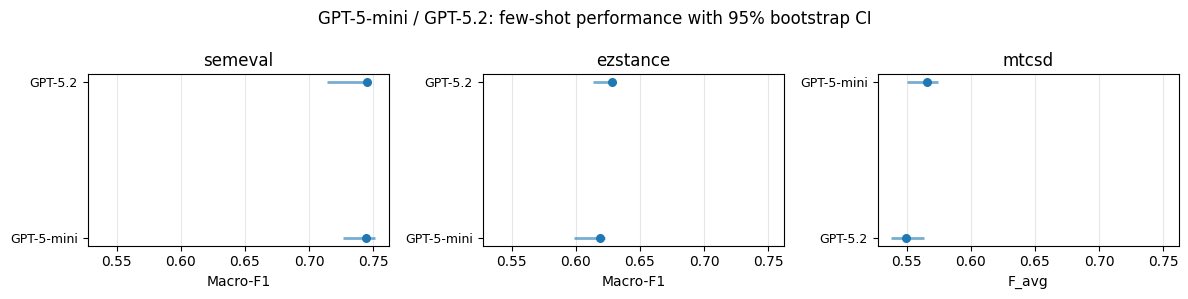

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)
for ax, dataset in zip(axes, DATASETS):
    sub = overall_ci[overall_ci["dataset"] == dataset].dropna(subset=["point"]).sort_values("point")
    y = np.arange(len(sub))
    ax.hlines(y, sub["ci_lo"], sub["ci_hi"], color="#1f77b4", alpha=0.6, linewidth=2)
    ax.scatter(sub["point"], y, color="#1f77b4", s=30, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["model"], fontsize=9)
    ax.set_title(dataset)
    ax.set_xlabel("Macro-F1" if dataset != "mtcsd" else "F_avg")
    ax.grid(axis="x", alpha=0.3)

fig.suptitle("GPT-5-mini / GPT-5.2: few-shot performance with 95% bootstrap CI")
plt.tight_layout()
plt.savefig(os.path.join(BASE, "data_out/stance/stance_analysis/gpt_fewshot_ci.png"), dpi=300, bbox_inches="tight")
plt.show()
